<a href="https://colab.research.google.com/github/ArielaMishaanCohen/ProyectoVC/blob/main/ProyectoVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final
Visión por Computadora  
Alina Carías, Daniel Machic, Ignacio Méndez, Ariela Mishaan y Diego Soto

- **DFL - Bundesliga Data Shootout**: https://www.kaggle.com/competitions/dfl-bundesliga-data-shootout

- **Github:** https://github.com/ArielaMishaanCohen/ProyectoVC.git

## Importaciones

In [47]:
!pip install datasets opencv-python pandas numpy matplotlib

In [48]:
!pip install -q kaggle datasets opencv-python

In [49]:
from google.colab import files
files.upload()  # sube kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "Disoto12",\r\n  "key": "KGAT_b75abeb30bac9773d16c35b5a66fcf34"\r\n}'}

In [50]:
import os, shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [51]:
!mkdir -p /content/data/kaggle

!kaggle datasets download -d saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv \
  -p /content/data/kaggle \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv
License(s): CC-BY-SA-4.0
100% 10.1G/10.1G [01:40<00:00, 107MB/s]

User cancelled operation


In [52]:
import os

ruta_kaggle = "/content/data/kaggle"

for root, dirs, files in os.walk(ruta_kaggle):
    print(root, len(files))
    print(files[:5])

/content/data/kaggle 1
['-dfl-bundesliga-460-mp4-videos-in-30sec-csv.zip']
/content/data/kaggle/DFL Bundesliga Data Shootout 0
[]
/content/data/kaggle/DFL Bundesliga Data Shootout/test 36
['test (22).mp4', 'test (25).mp4', 'test (11).mp4', 'test (32).mp4', 'test (24).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train 1
['train.csv']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/E3c993bd2_0 81
['E3c993bd2_0 (60).mp4', 'E3c993bd2_0 (7).mp4', 'E3c993bd2_0 (12).mp4', 'E3c993bd2_0 (17).mp4', 'E3c993bd2_0 (61).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/B1606b0e6_1 92
['B1606b0e6_1 (29).mp4', 'B1606b0e6_1 (59).mp4', 'B1606b0e6_1 (51).mp4', 'B1606b0e6_1 (34).mp4', 'B1606b0e6_1 (54).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/C35bd9041_0 83
['C35bd9041_0 (57).mp4', 'C35bd9041_0 (10).mp4', 'C35bd9041_0 (5).mp4', 'C35bd9041_0 (82).mp4', 'C35bd9041_0 (20).mp4']
/content/data/kaggle/DFL Bundesliga Data Shootout/train/A1606b0e6_0 76
['A1606b0

In [53]:
import pandas as pd
import glob

csv_files = glob.glob("/content/data/kaggle/**/*.csv", recursive=True)
print(csv_files)

df_kaggle = pd.read_csv(csv_files[0])
df_kaggle.head()

['/content/data/kaggle/DFL Bundesliga Data Shootout/test/test.csv', '/content/data/kaggle/DFL Bundesliga Data Shootout/train/train.csv']


,Name,Folder Path
0,test (1).mp4,test
1,test (10).mp4,test
2,test (11).mp4,test
3,test (12).mp4,test
4,test (13).mp4,test


In [54]:
video_files = glob.glob("/content/data/kaggle/**/*.mp4", recursive=True)

print("Cantidad de videos:", len(video_files))
print(video_files[:5])

Cantidad de videos: 460
['/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (22).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (25).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (11).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (32).mp4', '/content/data/kaggle/DFL Bundesliga Data Shootout/test/test (24).mp4']


In [55]:
import cv2

video_path = video_files[0]

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duracion = frames / fps

print("FPS:", fps)
print("Frames:", frames)
print("Duración segundos:", duracion)

ret, frame = cap.read()
cap.release()

print(frame.shape)

FPS: 25.0
Frames: 750
Duración segundos: 30.0
(1080, 1920, 3)


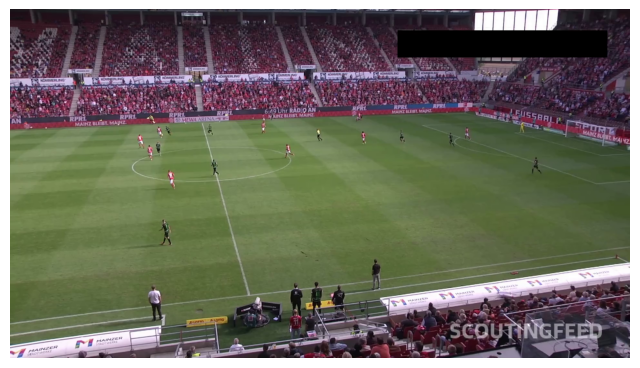

In [56]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## Hugging Face

In [57]:
!pip install -q datasets

In [58]:
from datasets import load_dataset

dataset_hf = load_dataset("dbal0503/Bundesliga")
dataset_hf

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['video_id', 'time', 'event', 'event_attributes'],
        num_rows: 11218
    })
})

In [59]:
df_hf = dataset_hf["train"].to_pandas()
df_hf.head()

,video_id,time,event,event_attributes
0,1606b0e6_0,200.265822,start,None
1,1606b0e6_0,201.150000,challenge,['ball_action_forced']
2,1606b0e6_0,202.765822,end,None
3,1606b0e6_0,210.124111,start,None
4,1606b0e6_0,210.870000,challenge,['opponent_dispossessed']


In [60]:
import cv2
import os

def extraer_frames(video_path, output_dir, cada_n_frames=30):
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    frame_id = 0
    saved_id = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % cada_n_frames == 0:
            nombre = f"frame_{saved_id:05d}.jpg"
            cv2.imwrite(os.path.join(output_dir, nombre), frame)
            saved_id += 1

        frame_id += 1

    cap.release()
    return saved_id

In [73]:
output_dir = "/content/frames/video_001"

cantidad = extraer_frames(video_files[0], output_dir, cada_n_frames=30)

print("Frames guardados:", cantidad)

Frames guardados: 25


## Exploración y limpieza

In [101]:
# Limpiar event_attributes
def limpiar_atributo(attr):
    if attr is None or (isinstance(attr, float)):
        return None
    if isinstance(attr, list):
        return attr[0] if len(attr) > 0 else None
    return str(attr).strip("[]'\" ")

df_hf['attr_clean'] = df_hf['event_attributes'].apply(limpiar_atributo)

# Solo eventos válidos (sin start/end)
EVENTOS_VALIDOS = ['play', 'challenge', 'throwin']
df_eventos = df_hf[df_hf['event'].isin(EVENTOS_VALIDOS)].copy()
df_eventos = df_eventos.dropna(subset=['video_id', 'time']).reset_index(drop=True)

print(f"\nEventos válidos: {len(df_eventos)}")
print(df_eventos['event'].value_counts())


Eventos válidos: 4382
event
play         3586
challenge     624
throwin       172
Name: count, dtype: int64


In [102]:
# Subtipos de challenge
SUBTIPOS_CHALLENGE = [
    'opponent_rounded',
    'ball_action_carried_out',
    'fouled',
    'opponent_dispossessed',
    'ball_action_forced',
    'possession_retained'
]

df_challenges = df_hf[df_hf['event'] == 'challenge'].copy()
df_challenge_typed = df_challenges[
    df_challenges['attr_clean'].isin(SUBTIPOS_CHALLENGE)
].copy().reset_index(drop=True)

print(f"Challenges con subtipo: {len(df_challenge_typed)}")
print(df_challenge_typed['attr_clean'].value_counts())

Challenges con subtipo: 571
attr_clean
ball_action_forced       239
opponent_dispossessed    138
fouled                   111
possession_retained       44
opponent_rounded          39
Name: count, dtype: int64


## Video_map

In [103]:
train_base = "/content/data/kaggle/DFL Bundesliga Data Shootout/train"

video_files_train = glob.glob(f"{train_base}/**/*.mp4", recursive=True)
print(f"Total mp4 en train: {len(video_files_train)}")

# Mapear video_id → lista de clips (cada video tiene varios clips de 30s)
video_map = {}
for vp in video_files_train:
    carpeta = os.path.basename(os.path.dirname(vp))  # ej: "A1606b0e6_0"
    vid_id = re.sub(r'^[A-Za-z]', '', carpeta)        # ej: "1606b0e6_0"
    if vid_id not in video_map:
        video_map[vid_id] = []
    video_map[vid_id].append(vp)

print(f"Video IDs únicos: {len(video_map)}")
print("Keys:", list(video_map.keys()))
print(f"\nMatches con HF: {df_eventos['video_id'].isin(video_map.keys()).sum()} / {len(df_eventos)}")

Total mp4 en train: 425
Video IDs únicos: 5
Keys: ['3c993bd2_0', '1606b0e6_1', '35bd9041_0', '1606b0e6_0', '35bd9041_1']

Matches con HF: 2087 / 4382


## Funciones de extracción

✅ Shape clip test: (8, 224, 224, 3)


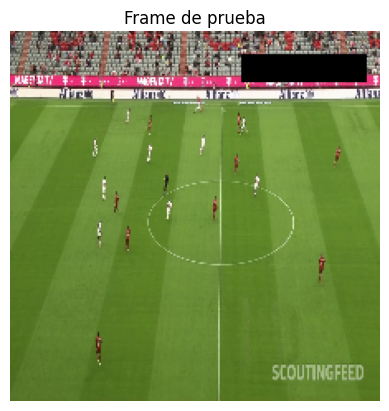

In [104]:
FRAME_SIZE = (224, 224)
FRAMES_PER_CLIP = 8

def get_clip_path(vid_id, tiempo, video_map):
    """Devuelve el mp4 correcto y el tiempo local dentro de ese clip."""
    clips = video_map.get(vid_id, [])
    if not clips:
        return None, 0

    def get_numero(path):
        m = re.search(r'\((\d+)\)', os.path.basename(path))
        return int(m.group(1)) if m else 0

    clips_sorted = sorted(clips, key=get_numero)
    clip_idx = min(int(tiempo // 30), len(clips_sorted) - 1)
    tiempo_local = tiempo % 30
    return clips_sorted[clip_idx], tiempo_local


def extraer_clip(video_path, tiempo_evento, fps, n_frames=FRAMES_PER_CLIP):
    """Extrae n_frames centrados en tiempo_evento. Retorna (n, 224, 224, 3) float32 0-1."""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_centro = int(tiempo_evento * fps)
    inicio = max(0, frame_centro - n_frames // 2)

    frames = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, inicio)
    for _ in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, FRAME_SIZE)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()

    while len(frames) < n_frames:
        frames.append(np.zeros((FRAME_SIZE[0], FRAME_SIZE[1], 3), dtype=np.uint8))

    return np.array(frames, dtype=np.float32) / 255.0


# Test rápido
path_test, t_local_test = get_clip_path('1606b0e6_0', 65.0, video_map)
clip_test = extraer_clip(path_test, t_local_test, fps=25.0)
print(" Shape clip test:", clip_test.shape)

# Visualizar primer frame del clip
plt.imshow(clip_test[0])
plt.axis('off')
plt.title('Frame de prueba')
plt.show()

## Modelo 1 (play/challenge/throwin)

In [105]:
LABEL_MAP_M1 = {'play': 0, 'challenge': 1, 'throwin': 2}
MAX_POR_CLASE = 80

X_m1, y_m1 = [], []
conteo_m1 = {k: 0 for k in LABEL_MAP_M1}
no_encontrados = 0

for _, row in df_eventos.iterrows():
    evento = str(row['event']).lower().strip()
    if evento not in LABEL_MAP_M1:
        continue
    if conteo_m1[evento] >= MAX_POR_CLASE:
        continue

    vid_id = str(row['video_id']).strip()
    tiempo = float(row['time'])

    clip_path, t_local = get_clip_path(vid_id, tiempo, video_map)
    if clip_path is None:
        no_encontrados += 1
        continue

    cap_tmp = cv2.VideoCapture(clip_path)
    fps_tmp = cap_tmp.get(cv2.CAP_PROP_FPS)
    cap_tmp.release()
    if fps_tmp == 0:
        fps_tmp = 25.0

    clip = extraer_clip(clip_path, t_local, fps_tmp)
    X_m1.append(clip)
    y_m1.append(LABEL_MAP_M1[evento])
    conteo_m1[evento] += 1

    if sum(conteo_m1.values()) % 30 == 0:
        print(f"  Progreso M1: {conteo_m1}")

X_m1 = np.array(X_m1)
y_m1 = np.array(y_m1)
print(f"\nDataset M1 listo — Shape: {X_m1.shape}")
print(f"Distribución: {conteo_m1} | No encontrados: {no_encontrados}")

  Progreso M1: {'play': 25, 'challenge': 4, 'throwin': 1}
  Progreso M1: {'play': 48, 'challenge': 9, 'throwin': 3}
  Progreso M1: {'play': 71, 'challenge': 15, 'throwin': 4}
  Progreso M1: {'play': 80, 'challenge': 29, 'throwin': 11}
  Progreso M1: {'play': 80, 'challenge': 51, 'throwin': 19}
  Progreso M1: {'play': 80, 'challenge': 76, 'throwin': 24}
  Progreso M1: {'play': 80, 'challenge': 80, 'throwin': 50}

✅ Dataset M1 listo — Shape: (228, 8, 224, 224, 3)
Distribución: {'play': 80, 'challenge': 80, 'throwin': 68} | No encontrados: 104


## Modelo 2 (subtipos de challenge)

In [106]:
LABEL_MAP_M2 = {s: i for i, s in enumerate(SUBTIPOS_CHALLENGE)}
MAX_POR_SUBTIPO = 50

X_m2, y_m2 = [], []
conteo_m2 = {k: 0 for k in LABEL_MAP_M2}
no_encontrados_m2 = 0

for _, row in df_challenge_typed.iterrows():
    subtipo = row['attr_clean']
    if subtipo not in LABEL_MAP_M2:
        continue
    if conteo_m2[subtipo] >= MAX_POR_SUBTIPO:
        continue

    vid_id = str(row['video_id']).strip()
    tiempo = float(row['time'])

    clip_path, t_local = get_clip_path(vid_id, tiempo, video_map)
    if clip_path is None:
        no_encontrados_m2 += 1
        continue

    cap_tmp = cv2.VideoCapture(clip_path)
    fps_tmp = cap_tmp.get(cv2.CAP_PROP_FPS)
    cap_tmp.release()
    if fps_tmp == 0:
        fps_tmp = 25.0

    clip = extraer_clip(clip_path, t_local, fps_tmp)
    X_m2.append(clip)
    y_m2.append(LABEL_MAP_M2[subtipo])
    conteo_m2[subtipo] += 1

    if sum(conteo_m2.values()) % 20 == 0:
        print(f"  Progreso M2: {conteo_m2}")

X_m2 = np.array(X_m2)
y_m2 = np.array(y_m2)
print(f"\n✅ Dataset M2 listo — Shape: {X_m2.shape}")
print(f"Distribución: {conteo_m2} | No encontrados: {no_encontrados_m2}")

  Progreso M2: {'opponent_rounded': 2, 'ball_action_carried_out': 0, 'fouled': 2, 'opponent_dispossessed': 10, 'ball_action_forced': 5, 'possession_retained': 1}
  Progreso M2: {'opponent_rounded': 4, 'ball_action_carried_out': 0, 'fouled': 8, 'opponent_dispossessed': 13, 'ball_action_forced': 9, 'possession_retained': 6}
  Progreso M2: {'opponent_rounded': 6, 'ball_action_carried_out': 0, 'fouled': 13, 'opponent_dispossessed': 20, 'ball_action_forced': 15, 'possession_retained': 6}
  Progreso M2: {'opponent_rounded': 8, 'ball_action_carried_out': 0, 'fouled': 15, 'opponent_dispossessed': 23, 'ball_action_forced': 24, 'possession_retained': 10}
  Progreso M2: {'opponent_rounded': 10, 'ball_action_carried_out': 0, 'fouled': 15, 'opponent_dispossessed': 31, 'ball_action_forced': 31, 'possession_retained': 13}
  Progreso M2: {'opponent_rounded': 12, 'ball_action_carried_out': 0, 'fouled': 22, 'opponent_dispossessed': 34, 'ball_action_forced': 35, 'possession_retained': 17}
  Progreso M2: 

## Arquitectura

In [107]:
def build_efficientnet(n_clases, n_frames=FRAMES_PER_CLIP):
    frame_input = tf.keras.Input(shape=(n_frames, 224, 224, 3))
    base = EfficientNetB0(include_top=False, weights='imagenet', pooling='avg')
    base.trainable = False
    features = layers.TimeDistributed(base)(frame_input)
    x = layers.GlobalAveragePooling1D()(features)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_clases, activation='softmax')(x)
    return models.Model(inputs=frame_input, outputs=out)